# Neon Web Traffic — Sample Logs Spectacle

Dashboard exported from example-mcp-dashbuilder


In [1]:
from elasticsearch import Elasticsearch
import pandas as pd
import matplotlib.pyplot as plt

es = Elasticsearch(
    "http://localhost:9200",
    basic_auth=("elastic", "changeme"),
)


/Users/stratoula/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Total requests

Chart type: **metric**


In [2]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS lines = COUNT(*)
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
print(f"Total requests: {df.iloc[0]['lines']}")


Total requests: 14074


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/935307243.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/1707163018.py:2: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  trend_result = es.esql.query(


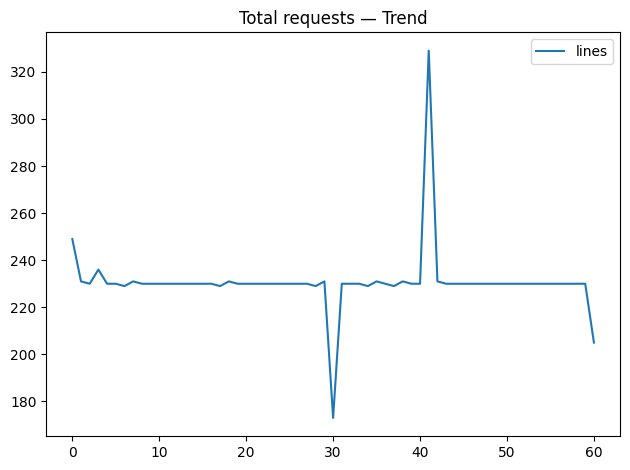

In [3]:
# Total requests — trend sparkline
trend_result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS lines = COUNT(*) BY ts = BUCKET(@timestamp, 1 day) | SORT ts
    """,
    format="json"
)

trend_df = pd.DataFrame(trend_result["values"], columns=[c["name"] for c in trend_result["columns"]])
trend_df.plot(title="Total requests — Trend")
plt.tight_layout()
plt.show()


## Bytes served

Chart type: **metric**


In [4]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS mib = ROUND(SUM(bytes)/1048576, 1)
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
print(f"Bytes served: {df.iloc[0]['mib']}")


Bytes served: 76


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/452739195.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


## Geo destinations

Chart type: **metric**


In [5]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS regions = COUNT_DISTINCT(geo.dest)
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
print(f"Geo destinations: {df.iloc[0]['regions']}")


Geo destinations: 173


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/837987204.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


## HTTP error rate

Chart type: **metric**


In [6]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS total = COUNT(*), errors = COUNT(*) WHERE TO_INTEGER(`response.keyword`) >= 400 | EVAL err_pct = ROUND(100.0 * errors / total, 2)
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
print(f"HTTP error rate: {df.iloc[0]['err_pct']}")


HTTP error rate: 8.82


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/3001834255.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


## Traffic pulse (daily)

Chart type: **area**


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/2222782088.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


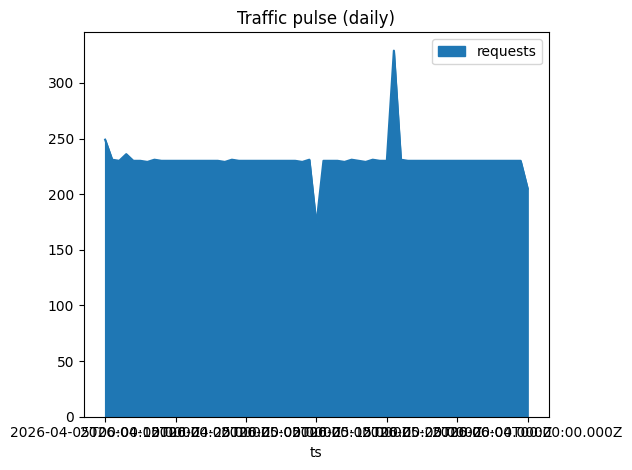

In [7]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS requests = COUNT(*) BY ts = BUCKET(@timestamp, 1 day) | SORT ts
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
df.plot.area(x="ts", y=["requests"], title="Traffic pulse (daily)")
plt.tight_layout()
plt.show()


## Top HTTP status codes

Chart type: **bar**


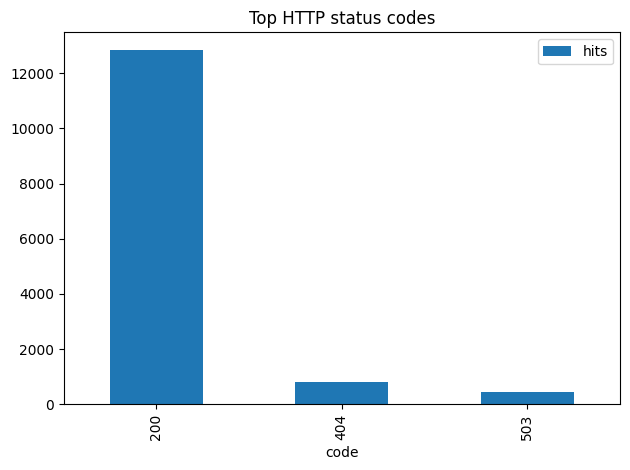

In [8]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS hits = COUNT(*) BY code = response.keyword | SORT hits DESC | LIMIT 10
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
df.plot.bar(x="code", y=["hits"], title="Top HTTP status codes")
plt.tight_layout()
plt.show()


## Requests by OS (top 6)

Chart type: **pie**


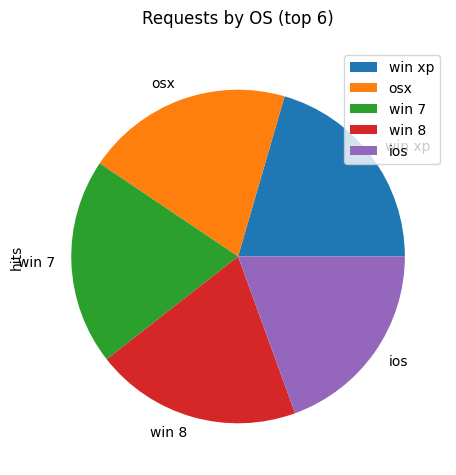

In [9]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | STATS hits = COUNT(*) BY os = machine.os.keyword | SORT hits DESC | LIMIT 6
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
df.set_index("os")[["hits"]].plot.pie(subplots=True, title="Requests by OS (top 6)")
plt.tight_layout()
plt.show()


## When the internet glows (day × hour)

Chart type: **heatmap**


In [10]:
result = es.esql.query(
    query="""
    FROM kibana_sample_data_logs | EVAL day = DATE_FORMAT("EEEE", @timestamp), hour = DATE_FORMAT("HH", @timestamp) | STATS hits = COUNT(*) BY day, hour | SORT day, hour
    """,
    format="json"
)

df = pd.DataFrame(result["values"], columns=[c["name"] for c in result["columns"]])
import seaborn as sns
pivot = df.pivot_table(index="day", columns="hour", values="hits")
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("When the internet glows (day × hour)")
plt.tight_layout()
plt.show()


/var/folders/cn/rd9ggb657gxf0chyt7c1w_600000gn/T/ipykernel_81621/1039185547.py:1: ElasticsearchWarning: No limit defined, adding default limit of [1000]
  result = es.esql.query(


ModuleNotFoundError: No module named 'seaborn'